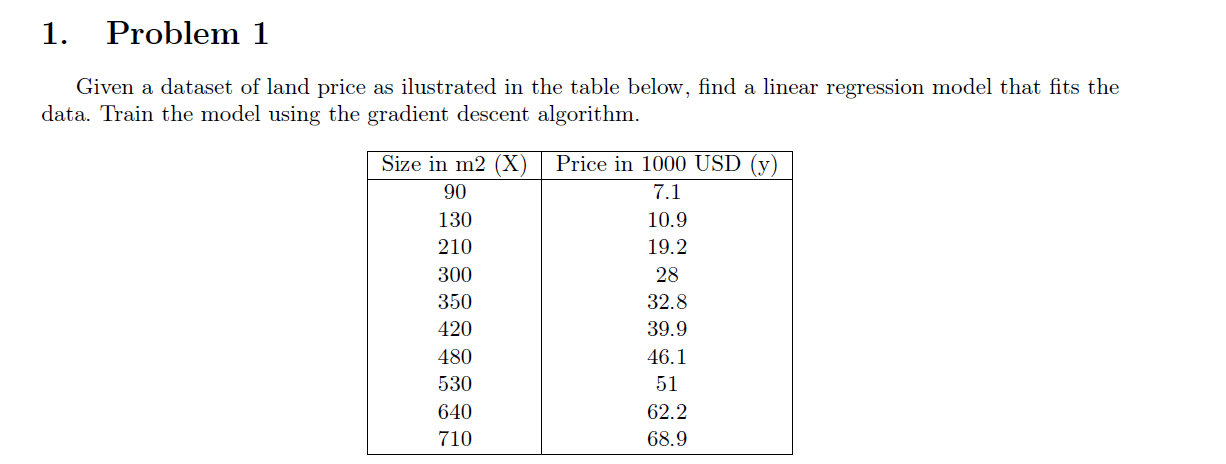

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

<Axes: >

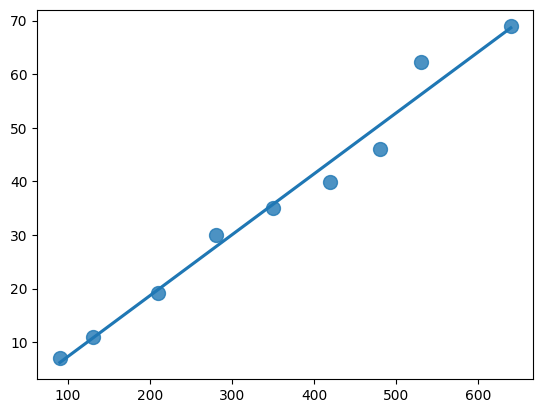

In [2]:
# Data from Problem 1
X = np.array([90, 130, 210, 280, 350, 420, 480, 530, 640])
y = np.array([7.1, 10.9, 19.2, 30, 35, 39.9, 46.1, 62.2, 68.9])
# plot data to scatter plot to visualize the data and decide on the model to fit
sns.regplot(x=X, y=y, ci=None, scatter_kws={"s": 100})

In [3]:
def grad(X: float, y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        One feature only \n
        feature and label will be scaled in this function
        >>> X: feature
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning rate
        >>> b_lr: bias learning rate
    '''
    X = X / np.max(X)
    
    w = 0
    b = 0

    for i in range(1, iter - 1):

        y_new = w * X + b
        
        weight = np.mean((y_new - y) * 2 * X)
        bias = np.mean((y_new - y) * 2)
        
        w = w - w_lr * weight
        b = b - b_lr * bias

    y_new = w * X + b
    loss = np.mean(pow(y - y_new, 2))

    return w, b, loss


In [4]:
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710])
y = np.array([7.1, 10.9, 19.2, 28.0, 32.8, 39.9, 46.1, 51.0, 62.2, 68.9])

a = grad(X, y, 10000, 0.01, 0.01)
w = a[0]
b = a[1]
loss = a[2]
w = w / np.max(X)
print(f"Weight: {w:.6f}")
print(f"Bias: {b:.6f}")
print(f"loss: {loss:.6f}")
print(f"y = {w:.5f}x {b:.2f} ")


Weight: 0.099980
Bias: -1.982317
loss: 0.016885
y = 0.09998x -1.98 


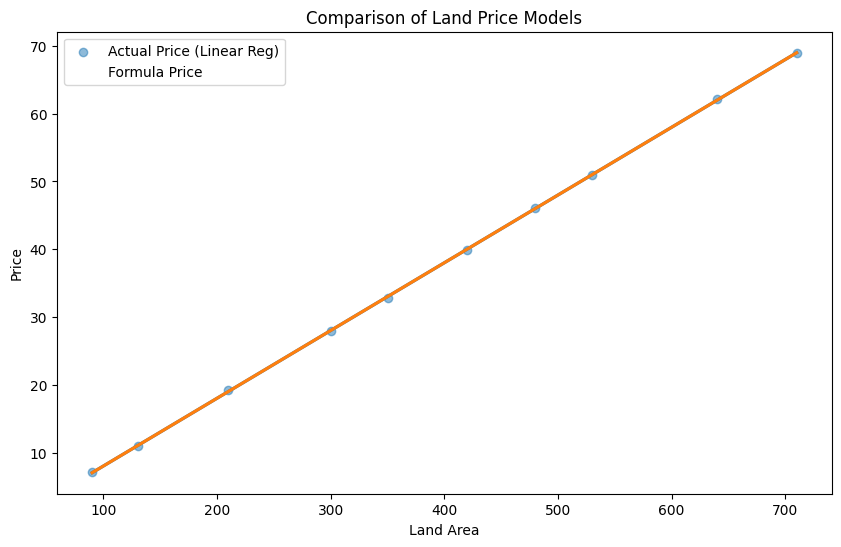

In [5]:
# 1. Load data once
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710])
Y_actual = np.array([7.1, 10.9, 19.2, 28.0, 32.8, 39.9, 46.1, 51.0, 62.2, 68.9])

# 2. Calculate your custom regression/formula values
Y_formula = 0.09998 * X + -1.98 

# 3. Plot both on the same graph
plt.figure(figsize=(10, 6))

# Original data points and regression
sns.regplot(x=X, y=Y_actual, ci=None, label='Actual Price (Linear Reg)', scatter_kws={'alpha':0.5})

# Your custom formula line
sns.regplot(x=X, y=Y_formula, ci=None, label='Formula Price', marker="")

# 4. Add details to make it readable
plt.xlabel('Land Area')
plt.ylabel('Price')
plt.title('Comparison of Land Price Models')
plt.legend()
plt.show()

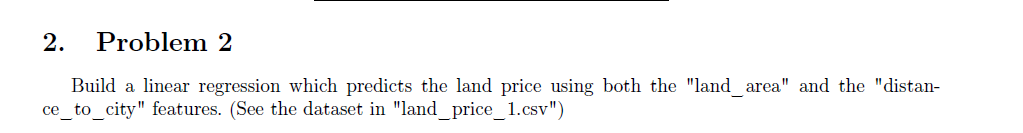

In [6]:
def grad(X1: float,X2:float , y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        One feature only \n
        feature and label will be scaled in this function
        >>> X1: Land area
        >>> X2: distance to city
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning  X1 and X2
        >>> b_lr: bias learning rate
    '''
    X1 = X1 / np.max(X1)
    X2 = X2 / np.max(X2)
    
    w1 = 0
    w2 = 0
    b = 0

    for i in range(1, iter - 1):

        y_new = w1 * X1 + w2 * X2 + b
        
        weight1 = np.mean((y_new - y) * 2 * X1)
        weight2 = np.mean((y_new - y) * 2 * X2)
        
        bias = np.mean((y_new - y) * 2)
        
        w1 = w1 - w_lr * weight1
        w2 = w2 - w_lr * weight2
        b = b - b_lr * bias

    y_new = w1 * X1 + w2 * X2 + b
    loss = np.mean(pow(y - y_new, 2))

    return w1,w2, b, loss


In [7]:
# Load the data
df = pd.read_csv('land_price_1.csv')
X1 = df['land_area'].values
X2 = df['dist_to_city'].values
y = df['price'].values


a = grad(X1,X2, y, 10000, 0.01, 0.01)
w1 = a[0]
w2 = a[1]
b = a[2]
loss = a[3]
w1 = w1 / np.max(X1)
w2 = w2 /np.max(X2)
print(f"Weight1: {w1:.6f}")
print(f"Weight2: {w2:.6f}")
print(f"Bias: {b:.6f}")
print(f"loss: {loss:.6f}")
print(f"y = {w1:.5f} x1 {w2:.5f} x2 + {b:.2f} ")



Weight1: 0.100177
Weight2: -2.010959
Bias: 29.916129
loss: 0.364475
y = 0.10018 x1 -2.01096 x2 + 29.92 


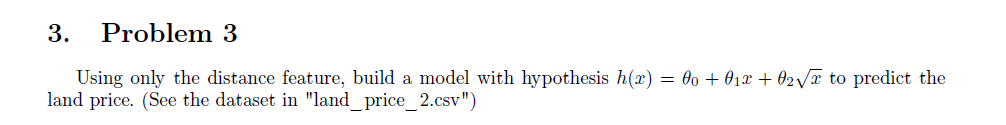

<Axes: >

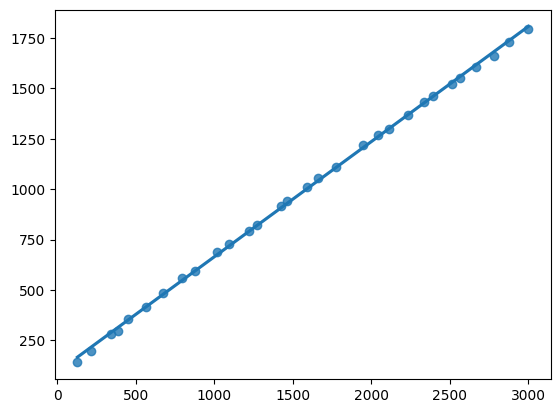

In [8]:
# Load the data
df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
Y = df['price'].values
sns.regplot(x=X,y=Y,ci = None)

is a liner regression

In [9]:
def grad(X_raw, y_raw, iterations, lr):
    # 1. Scaling for stability (Min-Max scaling is safer)
    x_max = np.max(X_raw)
    y_max = np.max(y_raw)
    
    X = X_raw / x_max
    y = y_raw / y_max
    
    # Initialize parameters
    w1, w2, b = 0.0, 0.0, 0.0
    n = len(X)
    sqrt_X = np.sqrt(X)

    for i in range(iterations):
        # Prediction
        y_pred = w1 * X + w2 * sqrt_X + b
        
        # Calculate Gradients (MSE Derivatives)
        error = y_pred - y
        dw1 = (2/n) * np.sum(error * X)
        dw2 = (2/n) * np.sum(error * sqrt_X)
        db = (2/n) * np.sum(error)
        
        # Update weights
        w1 -= lr * dw1
        w2 -= lr * dw2
        b -= lr * db

    # Final Loss (on scaled data)
    final_pred = w1 * X + w2 * sqrt_X + b
    loss = np.mean((y - final_pred)**2)

    # Convert weights back to original scale
    # y_orig = y_max * (w1*(X_orig/x_max) + w2*sqrt(X_orig/x_max) + b)
    w1_final = w1 * (y_max / x_max)
    w2_final = w2 * (y_max / np.sqrt(x_max))
    b_final = b * y_max

    return w1_final, w2_final, b_final, loss

# Usage
df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
y = df['price'].values

w1, w2, b, loss = grad(X, y, 10000, 0.1)

print(f"Weight1: {w1:.6f}")
print(f"Weight2: {w2:.6f}")
print(f"Bias: {b:.6f}")
print(f"y = {w1:.5f}x + {w2:.5f}√x + {b:.2f}")

Weight1: 0.481133
Weight2: 6.385668
Bias: -5.914964
y = 0.48113x + 6.38567√x + -5.91


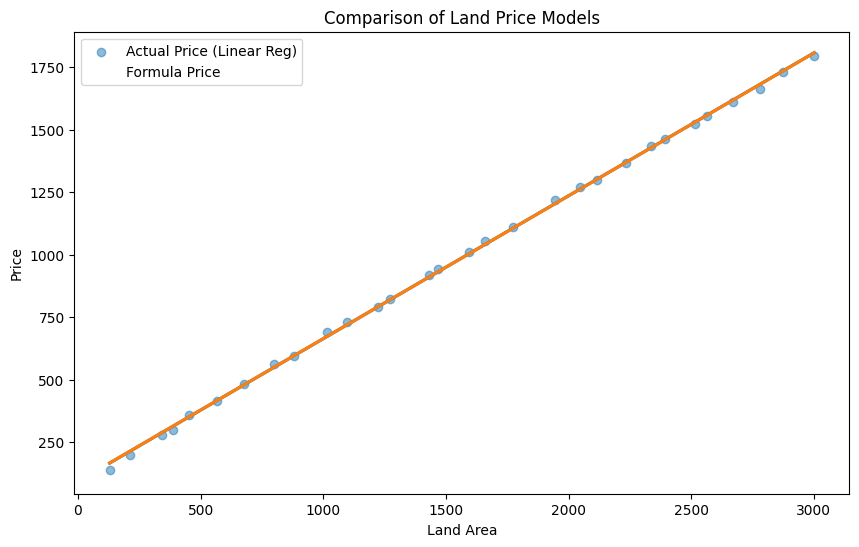

In [10]:
# 1. Load data once
df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
Y_actual = df['price'].values

# 2. Calculate your custom regression/formula values
Y_formula = 0.48113 * X + 6.38567 * np.sqrt(X) + -5.91

# 3. Plot both on the same graph
plt.figure(figsize=(10, 6))

# Original data points and regression
sns.regplot(x=X, y=Y_actual, ci=None, label='Actual Price (Linear Reg)', scatter_kws={'alpha':0.5})

# Your custom formula line
sns.regplot(x=X, y=Y_formula, ci=None, label='Formula Price', marker="")

# 4. Add details to make it readable
plt.xlabel('Land Area')
plt.ylabel('Price')
plt.title('Comparison of Land Price Models')
plt.legend()
plt.show()

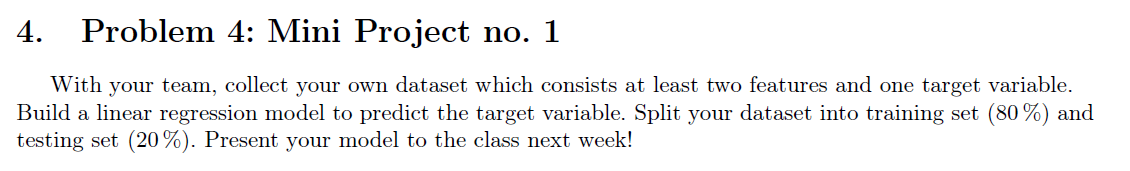

we didn't do survey from our friend but we get a dataset about price houses from Khmer24 and Realestate.com.kh because it look similar to the prevoius exercise

In [11]:
df = pd.read_csv('PP_houses_prices .csv')
df.head()

,Size_m2,Bedrooms,Bathrooms,Location,Dist_CityCenter_km,Parking,Price_USD
0,120,3,2,Chamkarmon,5.2,1,145000
1,95,2,1,Toul Kork,7.1,1,108000
2,210,4,3,Sen Sok,8.8,1,210000
3,75,2,1,Meanchey,10.4,0,85000
4,160,3,2,Boeung Keng Kang,4.5,1,185000


In [ ]:
size = df['Size_m2'].values
bedrooms = df['Bedrooms'].values
bathrooms = df['Bathrooms'].values
dist_to_city = df['Dist_CityCenter_km'].values
parking = df['Parking'].values
price = df['Price_USD'].values #lebel

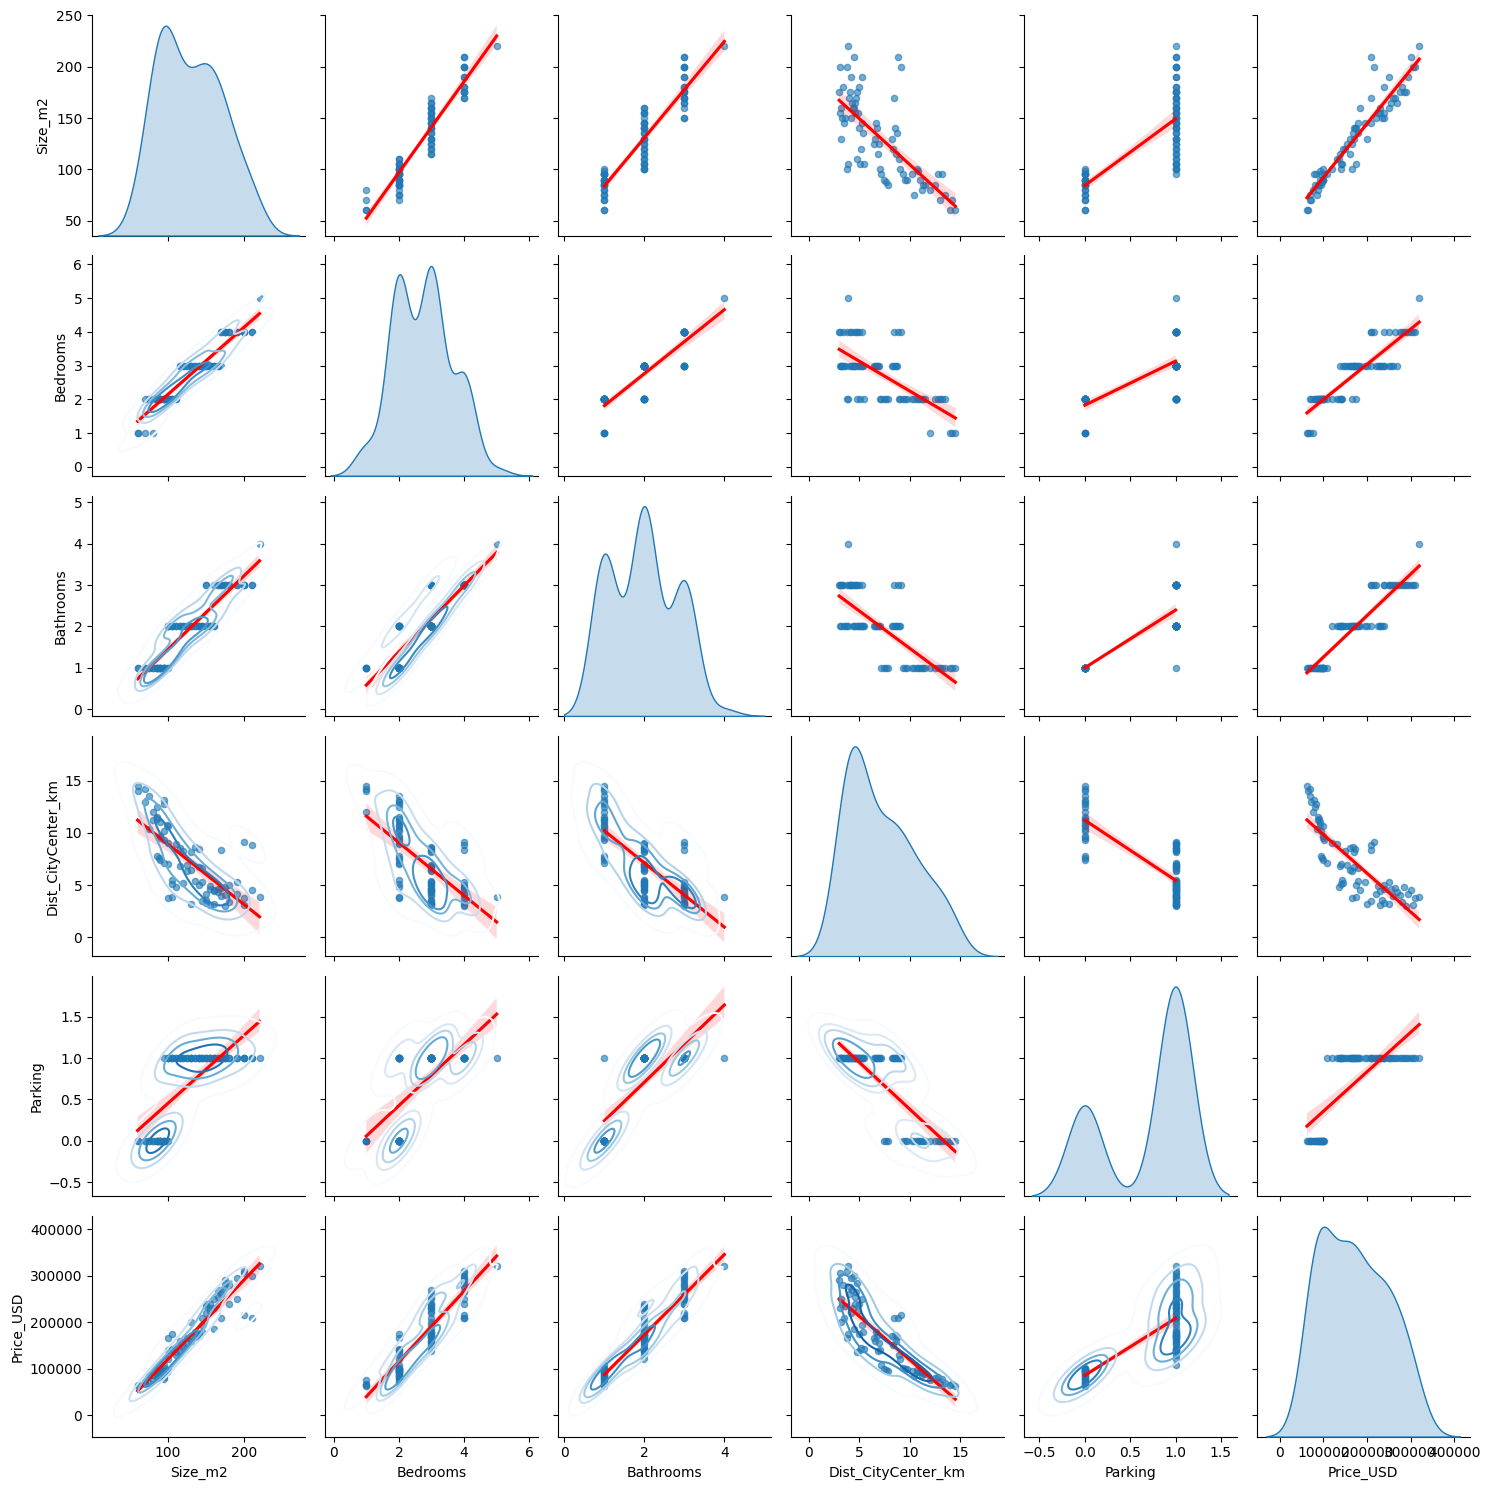

In [17]:
g = sns.pairplot(df,
                 kind='reg',          # <– adds the trend/regression line
                 diag_kind='kde',
                 plot_kws={
                     'scatter_kws': {'s':20,'alpha':.6},
                     'line_kws':    {'color':'red'}})   # line style

# you can still overlay contours if you like
g.map_lower(sns.kdeplot, levels=5, cmap='Blues', fill=False)

plt.tight_layout()
plt.show()

look liner enough let start working

In [ ]:
#scale down the data for better performance
size = size / np.max(size)
bedrooms = bedrooms / np.max(bedrooms)
bathrooms = bathrooms / np.max(bathrooms)
dist_to_city = dist_to_city / np.max(dist_to_city)
parking = parking / np.max(parking)
price = price / np.max(price)
#declear the weight and bias
w_size,w_bedrooms,w_bathrooms,w_dist,w_parking = 0,0,0,0,0
b=0
#learing rate
lr = 0.01
#number of iterations
iterations = 100000
for i in range(iterations):
    #predict the price
    price_pred = w_size * size + w_bedrooms * bedrooms + w_bathrooms * bathrooms + w_dist * dist_to_city + w_parking * parking + b
    
    #calculate the error
    error = price_pred - price
    
    #calculate the gradients
    dw_size = (2/len(size)) * np.sum(error * size)
    dw_bedrooms = (2/len(bedrooms)) * np.sum(error * bedrooms)
    dw_bathrooms = (2/len(bathrooms)) * np.sum(error * bathrooms)
    dw_dist = (2/len(dist_to_city)) * np.sum(error * dist_to_city)
    dw_parking = (2/len(parking)) * np.sum(error * parking)
    db = (2/len(price)) * np.sum(error)
    
    #update the weights and bias
    w_size -= lr * dw_size
    w_bedrooms -= lr * dw_bedrooms
    w_bathrooms -= lr * dw_bathrooms
    w_dist -= lr * dw_dist
    w_parking -= lr * dw_parking
    b -= lr * db
#final loss
price_pred = w_size * size + w_bedrooms * bedrooms + w_bathrooms * bathrooms + w_dist * dist_to_city + w_parking * parking + b
loss = np.mean((price - price_pred)**2)
print(f"Weight for Size: {w_size:.6f}")
print(f"Weight for Bedrooms: {w_bedrooms:.6f}")
print(f"Weight for Bathrooms: {w_bathrooms:.6f}")
print(f"Weight for Distance to City: {w_dist:.6f}")
print(f"Weight for Parking: {w_parking:.6f}")
print(f"Bias: {b:.6f}")
print(f"Final Loss: {loss:.6f}")
print(f"Price = ({w_size:.5f})*Size + ({w_bedrooms:.5f})*Bedrooms + ({w_bathrooms:.5f})*Bathrooms + ({w_dist:.5f})*Dist_to_City + ({w_parking:.5f})*Parking + {b:.2f}")

Weight for Size: 0.448523
Weight for Bedrooms: 0.212614
Weight for Bathrooms: 0.371689
Weight for Distance to City: -0.324659
Weight for Parking: -0.062297
Bias: 0.175821
Final Loss: 0.002513
Price = (0.44852)*Size + (0.21261)*Bedrooms + (0.37169)*Bathrooms + (-0.32466)*Dist_to_City + (-0.06230)*Parking + 0.18


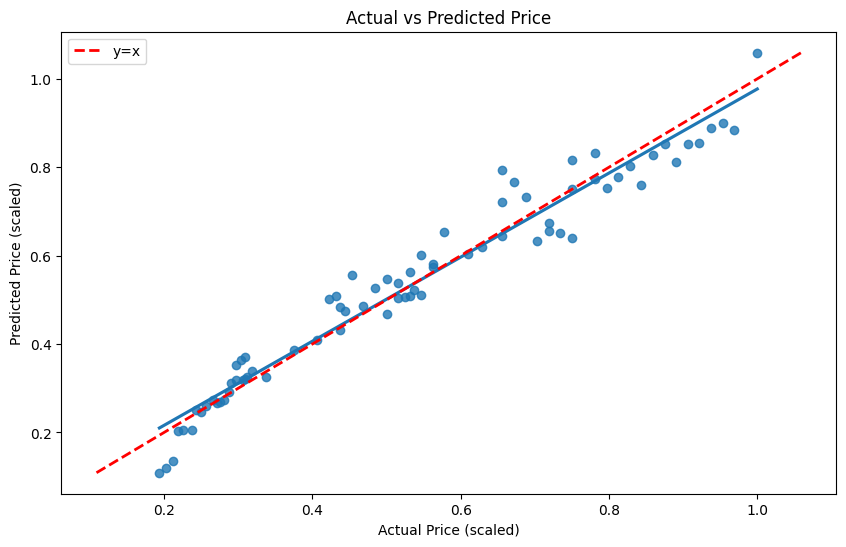

In [30]:
price_pred = w_size * size + w_bedrooms * bedrooms + w_bathrooms * bathrooms + w_dist * dist_to_city + w_parking * parking + b

plt.figure(figsize=(10, 6))
sns.regplot(x=price, y=price_pred, ci=None)

# Add y=x line
min_val = min(price.min(), price_pred.min())
max_val = max(price.max(), price_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')

plt.xlabel('Actual Price (scaled)')
plt.ylabel('Predicted Price (scaled)')
plt.title('Actual vs Predicted Price')
plt.legend()  # optional
plt.show()